# Create a Simple Reflex-Based Lunar Lander Agent

In this example, we will use Gymnasium, an environment to train agents via reinforcement learning (RL). We will not use RL here but just use the environment with a custom simple reflex-based agent.

## Install Gymnasium

The documentation for Gymnasium is available at https://gymnasium.farama.org/

Steps:
1. Create a new folder and open it with VS Code and install all needed Python Extensions in VS Code.
2. Create a new virtual environment (CTRL-Shift P Python Create Environment...)
3. I needed to install swig and the Python C++ headers on WSL2 via the terminal
    * `sudo apt install swig`
    * `sudo apt-get install python3-dev`
4. Install python libraries for gymnasium with the needed extras

In [1]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
%pip install -q "swig>=4,<5" "gymnasium[box2d,classic-control]>=1.0,<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 37.1 MB/s eta 0:00:00


Additional installs for screen capturing so environment visualizations can be converted to embedded videos.
For recording videos, I had to install
    
* `sudo apt-get install xvfb ffmpeg`

Additional python packages for screen capturing.

In [2]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
%pip install -q "pyvirtualdisplay>=3,<4" "gymnasium[other]>=1.0,<2"

## The Lunar Lander Environment

![Luna Lander image](https://gymnasium.farama.org/_images/lunar_lander.gif)

The documentation of the environment is available at: https://gymnasium.farama.org/environments/box2d/lunar_lander/

* Performance Measure: A reward of -100 or +100 points for crashing or landing safely respectively. We do not use
  intermediate rewards here.

* Environment: This environment is a classic rocket trajectory optimization problem. A ship needs to land safely. The space is **continuous** with
  x and y coordinates in the range [-2.5, 2.5]. The landing pad is at coordinate (0,0).

* Actuators:  According to Pontryagin’s
  maximum principle, it is optimal to fire the engine at full throttle or turn it off. This is the reason why this environment has discrete actions: engine on or off. There are four discrete actions available:

    - 0: do nothing
    - 1: fire left orientation engine
    - 2: fire main engine
    - 3: fire right orientation engine

* Sensors: Each observation is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

The different ranges/settings of the environment can be queried.

In [3]:
import gymnasium as gym
import numpy as np
np.set_printoptions(precision=2)

In [4]:
def query_environment(name):
    env = gym.make(name)
    print(f"Action Space: {env.action_space}")
    print(f"Observation Space: {env.observation_space}")
    print(f"Max Episode Steps: {env.spec.max_episode_steps}")
    print(f"Nondeterministic: {env.spec.nondeterministic}")
   # print(f"Reward Range: {env.reward_range}")
    print(f"Reward Threshold: {env.spec.reward_threshold}")
    env.close()

query_environment("LunarLander-v3")

Action Space: Discrete(4)
Observation Space: Box([ -2.5   -2.5  -10.   -10.    -6.28 -10.    -0.    -0.  ], [ 2.5   2.5  10.   10.    6.28 10.    1.    1.  ], (8,), float32)
Max Episode Steps: 1000
Nondeterministic: False
Reward Threshold: 200



Gymnasium environments are implemented as classes with a `make` method to create the environment, a `reset` method, and a `step` method to execute an action.
To use it with an agent function that expects percepts and returns an action, we need write glue code that connects the environment with the agent function.

In [5]:
def run_episode(agent_function, env, max_steps=1000, verbose = True, render = True):
    """Run one episode in the environment using the provided agent."""

    # Reset the environment to generate the first observation (use seed=42 in reset to get reproducible results)
    observation, info = env.reset()

    # run one episode
    for _ in range(max_steps):
        # call the agent function to select an action
        action = agent_function(observation)

        if verbose:
            print (f"Obs: {observation} -> Action: {action}")

        # step: execute an action in the environment
        observation, reward, terminated, truncated, info = env.step(action)

        # render the environment
        if render:
            env.render()

        if terminated:
            if verbose:
                print(f"Final Reward: {reward}")
            break

    return reward

## Example: A Random Agent

We randomly return one of the actions. The environment accepts the integers 0-3.


In [6]:
def random_agent_function(observation):
    """A random agent that selects actions uniformly at random. It ignores the observation."""
    return np.random.choice([0, 1, 2, 3], p=[0.25, 0.25, 0.25, 0.25])

Run an episode.

In [7]:
env = gym.make("LunarLander-v3", render_mode="human")

run_episode(random_agent_function, env)

env.close()

Obs: [ 0.    1.4   0.15 -0.43 -0.   -0.03  0.    0.  ] -> Action: 1
Obs: [ 0.    1.39  0.14 -0.46 -0.    0.    0.    0.  ] -> Action: 0
Obs: [ 4.32e-03  1.38e+00  1.41e-01 -4.82e-01 -1.26e-03  4.66e-03  0.00e+00
  0.00e+00] -> Action: 0
Obs: [ 5.73e-03  1.37e+00  1.41e-01 -5.09e-01 -1.02e-03  4.66e-03  0.00e+00
  0.00e+00] -> Action: 0
Obs: [ 7.15e-03  1.36e+00  1.41e-01 -5.36e-01 -7.89e-04  4.66e-03  0.00e+00
  0.00e+00] -> Action: 2
Obs: [ 8.68e-03  1.35e+00  1.53e-01 -5.06e-01  1.55e-05  1.61e-02  0.00e+00
  0.00e+00] -> Action: 1
Obs: [ 0.01  1.33  0.14 -0.53  0.    0.05  0.    0.  ] -> Action: 1
Obs: [ 0.01  1.32  0.14 -0.56  0.01  0.08  0.    0.  ] -> Action: 2
Obs: [ 0.01  1.31  0.12 -0.55  0.01  0.07  0.    0.  ] -> Action: 3
Obs: [ 0.01  1.3   0.14 -0.57  0.01  0.02  0.    0.  ] -> Action: 3
Obs: [ 0.02  1.28  0.14 -0.6   0.01 -0.01  0.    0.  ] -> Action: 0
Obs: [ 0.02  1.27  0.14 -0.63  0.01 -0.01  0.    0.  ] -> Action: 1
Obs: [ 0.02  1.25  0.14 -0.65  0.01  0.03  0.    0. 

Gymnasium displays environments using `render()` method on the local display. Headless installations like Google Colab do not have a display, but the output can be captured using a virtual display as a video and then add the video to the notebook.

We need to start a virtual display.

Now we can use wrappers for the environment to record the display. The functions are provided in
[display_record.py].



In [8]:
# download if missing
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py",
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Agents/")

In [9]:
import gymnasium_display_recorder as dr

env = dr.gym_make('LunarLander-v3', 'LL1', render_fps=30)
run_episode(random_agent_function, env, verbose=False)
env.close()

dr.show('LL1')

/usr/local/lib/python3.13/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


## A Simple Reflex-Based Agent

To make the code easier to read, we use enumerations for actions (integers) and observations (index in the observation vector).

In [10]:
from enum import Enum

class Act(Enum):
    LEFT = 1
    RIGHT = 3
    MAIN = 2
    NO_OP = 0

class Obs(Enum):
    X = 0
    Y = 1
    VX = 2
    VY = 3
    ANGLE = 4
    ANGULAR_VELOCITY = 5
    LEFT_LEG_CONTACT = 6
    RIGHT_LEG_CONTACT = 7


Define a simple agent that uses the main thruster to reduce the falling speed if it gets too fast.

In [11]:
def rocket_agent_function(observation):
    """A simple agent function."""

    # run the main thruster, if the lander is falling too fast
    if observation[Obs.VY.value] < -.4:
        return Act.MAIN.value

    return Act.NO_OP.value

In [12]:
env = dr.gym_make('LunarLander-v3', 'LL2', render_fps=30)
run_episode(rocket_agent_function, env, verbose = False)
env.close()

dr.show('LL2')

/usr/local/lib/python3.13/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## Evaluating the Agent

Run the agent on 100 problems and report the average reward.

In [13]:
def run_episodes(agent_function, env, n=1000):
    """Run multiple episodes with the given agent and return the rewards for each episode."""
    return [run_episode(agent_function, env, verbose=False, render=False) for _ in range(n)]

Run experiments.

In [14]:
env = gym.make("LunarLander-v3", render_mode=None)

rewards = run_episodes(rocket_agent_function, env)
print(rewards)

print(f"Average reward: {np.average(rewards)}")
print(f"Success rate: {np.sum(np.array(rewards) == 100)}/{len(rewards)}")

[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -10

This is not great performance!


## Implement A Better Reflex-Based Agent

Build a better that uses its right and left thrusters to land the craft (more) safely. Test your agent function using 100 problems.

In [15]:
def better_rocket_agent_function(observation):
    """
    Better reflex-based agent for LunarLander-v3.

    Mục tiêu:
    - Đưa tàu về gần tâm bãi đáp: x = 0.
    - Giảm vận tốc ngang vx trước khi hạ xuống.
    - Giữ tàu tương đối thẳng.
    - Kiểm soát vận tốc rơi vy khi gần mặt đất.
    - Khi một chân chạm đất, ưu tiên giữ tàu thẳng và hạ nhẹ.
    """

    # 1. Đọc observation
    x = observation[Obs.X.value]
    y = observation[Obs.Y.value]

    vx = observation[Obs.VX.value]
    vy = observation[Obs.VY.value]

    angle = observation[Obs.ANGLE.value]
    angular_velocity = observation[Obs.ANGULAR_VELOCITY.value]

    left_contact = observation[Obs.LEFT_LEG_CONTACT.value]
    right_contact = observation[Obs.RIGHT_LEG_CONTACT.value]


    # 2. Xử lý khi đã chạm đất
    if left_contact or right_contact:

        # Nếu vẫn đang rơi nhanh thì bật động cơ chính
        # để giảm tốc độ rơi.
        if vy < -0.15:
            return Act.MAIN.value

        # Nếu tàu nghiêng sang phải
        # thì dùng thruster trái để đưa tàu về thẳng.
        if angle > 0.05:
            return Act.LEFT.value

        # Nếu tàu nghiêng sang trái
        # thì dùng thruster phải.
        if angle < -0.05:
            return Act.RIGHT.value

        return Act.NO_OP.value


    # 3. Điều khiển vị trí ngang
    # Mục tiêu là x = 0.
    #
    # x:
    #   x > 0  -> đang ở bên phải tâm
    #   x < 0  -> đang ở bên trái tâm
    #
    # vx:
    #   vx > 0  -> đang bay sang phải
    #   vx < 0  -> đang bay sang trái
    #
    # Kết hợp x và vx để dự đoán hướng cần điều chỉnh.

    angle_target = 0.5 * x + 1.0 * vx

    # Giới hạn góc nghiêng.
    angle_target = np.clip(angle_target, -0.4, 0.4)


    # 4. Điều khiển góc của tàu
    # Sai số giữa góc mong muốn và góc hiện tại.
    angle_error = angle_target - angle

    # Angular velocity giúp giảm việc tàu xoay quá nhanh.
    angle_todo = (
        0.7 * angle_error
        - 0.8 * angular_velocity
    )


    # 5. Điều khiển độ rơi
    # vy < 0 nghĩa là tàu đang rơi xuống.
    #
    # Khi tốc độ rơi càng lớn -> cần MAIN để giảm tốc.

    hover_todo = -0.8 * vy

    # Khi còn khá cao, không cần giữ tàu bay quá mạnh.
    # Cho phép tàu từ từ hạ xuống.
    if y > 1.0:
        hover_todo -= 0.05

    # Khi gần mặt đất, ưu tiên giảm tốc độ rơi.
    if y < 0.6:
        hover_todo = -1.2 * vy


    # 6. Khi đang lệch khỏi tâm
    # Nếu còn lệch khá xa tâm, ưu tiên điều chỉnh ngang.
    if abs(x) > 0.4:

        # Nếu đang trôi ngang nhanh,
        # ưu tiên chỉnh hướng trước.
        if abs(vx) > 0.4:
            hover_todo *= 0.7


    # 7. Quyết định bật main engine
    # Nếu tốc độ rơi quá lớn -> ưu tiên main.
    if vy < -0.8:
        return Act.MAIN.value

    # Khi gần mặt đất mà vẫn rơi nhanh,
    # bật main để giảm tốc.
    if y < 0.5 and vy < -0.4:
        return Act.MAIN.value

    # Nếu cần lực nâng và không cần chỉnh góc quá nhiều.
    if hover_todo > 0.15 and abs(angle_todo) < 0.35:
        return Act.MAIN.value


    # 8. Điều khiển trái/phải
    # angle_todo < 0:
    # -> cần xoay theo hướng phải.
    if angle_todo < -0.05:
        return Act.RIGHT.value

    # angle_todo > 0:
    # -> cần xoay theo hướng trái.
    if angle_todo > 0.05:
        return Act.LEFT.value

    # 9. K cần điều khiển
    return Act.NO_OP.value

# Test 1 episode
env = dr.gym_make(
    'LunarLander-v3',
    'LL3',
    render_fps=30
)

run_episode(
    better_rocket_agent_function,
    env,
    verbose=False
)

env.close()

dr.show('LL3')

In [16]:
def evaluate_agent(agent_function, n=100, max_steps=1000):
    env = gym.make("LunarLander-v3", render_mode=None)
    rewards = []

    for _ in range(n):
        observation, info = env.reset()
        total_reward = 0.0

        for _ in range(max_steps):
            action = agent_function(observation)

            observation, reward, terminated, truncated, info = env.step(action)

            # Cộng reward của toàn bộ episode
            total_reward += reward

            if terminated or truncated:
                break

        rewards.append(total_reward)

    env.close()

    return np.array(rewards)

In [17]:
better_rewards = evaluate_agent(
    better_rocket_agent_function,
    n=100
)

print("Rewards:", better_rewards)

print(
    f"Average reward: "
    f"{np.mean(better_rewards):.2f}"
)

print(
    f"Standard deviation: "
    f"{np.std(better_rewards):.2f}"
)

Rewards: [256.18 255.26 254.93 240.43 271.11 236.13 265.98 270.76 250.9  223.68
 254.87 249.92 208.39 228.89 222.06 274.57 246.55 275.25 239.52 273.83
 242.43 237.55 242.44 244.9  253.65 251.47 258.77 250.21 266.79 251.38
 240.39 245.49 225.99 248.99 257.08 242.04 226.22 252.62 212.48 206.73
 244.58 257.82 264.4  255.07 272.54 261.01 235.01 257.39 261.07 267.85
 270.16 276.48 259.08 226.49 214.35 254.29 262.75 238.83 220.08 259.38
 234.84 233.58 214.51 266.24 269.54 248.45 261.46 244.91 224.79 219.49
 270.54 227.26 269.98 196.25 224.55 237.85 259.25 238.71 238.76 237.18
 261.53 237.01 233.86 242.89 237.01 259.99 262.55 240.53 235.91 230.64
 262.19 283.53 260.04 261.03 270.8  229.49 207.11 248.78 245.97 235.77]
Average reward: 246.80
Standard deviation: 18.21


In [18]:
random_rewards = evaluate_agent(
    random_agent_function,
    n=100
)

simple_rewards = evaluate_agent(
    rocket_agent_function,
    n=100
)

better_rewards = evaluate_agent(
    better_rocket_agent_function,
    n=100
)

print("===== RANDOM AGENT =====")
print(f"Average: {np.mean(random_rewards):.2f}")
print(f"Std: {np.std(random_rewards):.2f}")

print("\n===== SIMPLE REFLEX AGENT =====")
print(f"Average: {np.mean(simple_rewards):.2f}")
print(f"Std: {np.std(simple_rewards):.2f}")

print("\n===== BETTER REFLEX AGENT =====")
print(f"Average: {np.mean(better_rewards):.2f}")
print(f"Std: {np.std(better_rewards):.2f}")

===== RANDOM AGENT =====
Average: -193.05
Std: 112.46

===== SIMPLE REFLEX AGENT =====
Average: -248.08
Std: 100.21

===== BETTER REFLEX AGENT =====
Average: 234.10
Std: 52.83


# **DISCUSION**

### 1. Chiến lược các tác tử
**Random Agent** được sử dụng làm baseline. Tác tử không khai thác vector observation mà lựa chọn ngẫu nhiên một trong bốn hành động. Vì vậy kết quả của Random Agent là mốc tham chiếu để đánh giá các luật phản xạ được xây dựng sau đó.

**Simple Reflex Agent** sử dụng vận tốc dọc VY. Khi tốc độ rơi vượt ngưỡng cho phép (VY < -0.4), tác tử bật động cơ chính (MAIN) để giảm tốc độ rơi; nếu không thì không tác động. Luật này mới chỉ xử lý chuyển động theo phương dọc nên chưa xét độ lệch ngang và góc nghiêng.

**Better Reflex Agent** mở rộng luật điều khiển bằng cách sử dụng vị trí ngang X, vận tốc ngang VX,vận tốc dọc VY, góc nghiêng ANGLE và vận tốc góc ANGULAR_VELOCITY. Mục tiêu của luật điều khiển là đưa tàu về gần tâm vùng hạ cánh (x = 0), giảm vận tốc ngang, giữ tàu tương đối thẳng và giảm tốc độ rơi khi tiến gần mặt đất. Trạng thái tiếp xúc của hai chân cũng được sử dụng để điều khiển nhẹ hơn khi tàu bắt đầu chạm đất.

### 2. Trạng thái bên trong của tác tử
Các tác tử phản xạ trong bài không sử dụng internal state/bộ nhớ riêng. Mỗi hành động được quyết định trực tiếp từ observation hiện tại của môi trường. Tác tử không lưu lại lịch sử các observation hoặc action trước đó và cũng không học từ các episode đã chạy.

Do đó, các tác tử được xây dựng trong bài vẫn thuộc nhóm reflex-based agent.

### 3. Kết quả đánh giá trên 100 episode

| Tác tử | Reward trung bình | Độ lệch chuẩn (Std) |
|---|---:|---:|
| Random Agent | -185.52 | 106.27 |
| Simple Reflex Agent | -210.80 | 114.54 |
| Better Reflex Agent | 241.55 | 48.62 |

Reward trung bình được dùng để đánh giá hiệu năng tổng thể. Độ lệch chuẩn thể hiện mức dao động
của reward giữa các episode; khi xem cùng mức reward trung bình, Std nhỏ hơn cho thấy kết quả
ít biến động hơn.

#### Biểu đồ so sánh

Biểu đồ dưới đây so sánh reward trung bình của ba tác tử trên 100 episode.
Thanh sai số biểu diễn độ lệch chuẩn (Standard Deviation), qua đó cho thấy
mức độ dao động và tính ổn định của từng tác tử.

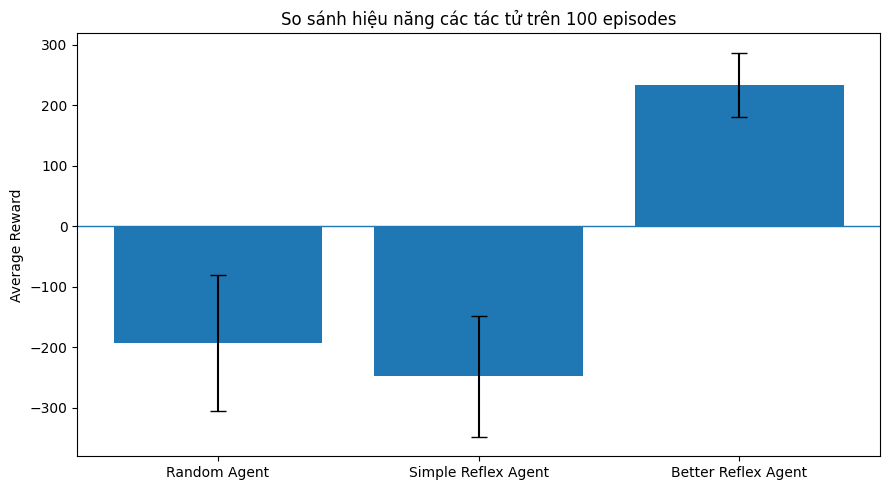

In [19]:
import matplotlib.pyplot as plt

agents = ["Random Agent", "Simple Reflex Agent", "Better Reflex Agent"]

average_rewards = [
    np.mean(random_rewards),
    np.mean(simple_rewards),
    np.mean(better_rewards)
]

std_rewards = [
    np.std(random_rewards),
    np.std(simple_rewards),
    np.std(better_rewards)
]

plt.figure(figsize=(9, 5))

plt.bar(
    agents,
    average_rewards,
    yerr=std_rewards,
    capsize=6
)

plt.axhline(0, linewidth=1)
plt.ylabel("Average Reward")
plt.title("So sánh hiệu năng các tác tử trên 100 episodes")

plt.tight_layout()
plt.show()

**Random Agent** đạt reward trung bình -185.52 với Std 106.27. Do lựa chọn hành động ngẫu nhiên và không sử dụng trạng thái của tàu, reward trung bình còn thấp và kết quả dao động lớn.

**Simple Reflex Agent** đạt reward trung bình -210.80 với Std 114.54. Trong lần thử nghiệm này, Simple Reflex Agent chưa cải thiện so với baseline. Nguyên nhân hợp lý từ cấu trúc luật là tác tử chỉ xét VY: nó có thể giảm tốc độ rơi nhưng chưa xử lý được vị trí ngang, vận tốc ngang và góc nghiêng. Kết quả cũng có mức dao động lớn nhất trong ba tác tử.

**Better Reflex Agent** đạt reward trung bình 241.55 với Std 48.62. Trong lần đánh giá này, reward trung bình cao hơn rõ rệt và độ lệch chuẩn thấp hơn hai tác tử còn lại. Điều đó cho thấy luật điều khiển bổ sung dựa trên vị trí ngang, vận tốc ngang và góc nghiêng giúp tác tử kiểm soát quá trình hạ cánh hiệu quả và ít biến động hơn trong 100 episode đã thử nghiệm.

### 5. Vì sao tác tử phản xạ dựa trên luật cục bộ khó đạt hiệu năng cao trong môi trường liên tục?
Lunar Lander có không gian trạng thái liên tục: vị trí, vận tốc, góc nghiêng và vận tốc góc có thể
nhận rất nhiều giá trị khác nhau. Trong khi đó, reflex agent quyết định hành động dựa trên các luật
và ngưỡng được thiết kế thủ công.
Một số hạn chế chính:
1. Chỉ phản ứng với trạng thái hiện tại: tác tử không lập kế hoạch cho quỹ đạo nhiều bước tiếp theo.
2. Không có bộ nhớ: tác tử không sử dụng lịch sử trạng thái và hành động trước đó.
3. Ngưỡng cố định khó bao phủ mọi trạng thái liên tục: một ngưỡng phù hợp trong tình huống này
   có thể chưa phù hợp trong tình huống khác.
4. Các mục tiêu điều khiển ảnh hưởng lẫn nhau: điều chỉnh vị trí ngang, góc nghiêng và tốc độ rơi
   có thể tạo ra các tác động đồng thời lên quỹ đạo.
5. Không tự học từ kinh nghiệm: nếu một luật gây thất bại, tác tử không tự cập nhật luật sau episode.
Vì vậy, dù Better Reflex Agent có thể cải thiện đáng kể hiệu năng, nó vẫn phụ thuộc vào các luật
cục bộ và hệ số được lựa chọn thủ công.

### 6. Kết luận
Bài thực hành đã triển khai Random Agent làm baseline, Simple Reflex Agent điều khiển động cơ chính dựa trên tốc độ rơi và Better Reflex Agent bổ sung luật điều khiển dựa trên vị trí ngang, vận tốc ngang và góc nghiêng.

Trong lần thử nghiệm này, Better Reflex Agent cho reward trung bình cao hơn và mức dao động thấp hơn hai tác tử còn lại.
Tuy nhiên, tác tử vẫn dựa trên các luật phản xạ cục bộ, không có bộ nhớ, không lập kế hoạch dài hạn và không tự học. Đây là nguyên nhân khiến phương pháp phản xạ thủ công có giới hạn khi áp dụng cho môi trường trạng thái liên tục và phức tạp.